[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/storopoli/ciencia-de-dados/main?filepath=notebooks%2FAula_19_Redes_Neurais_Convolucionais_com_PyTorch.ipynb)
<br>
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/storopoli/ciencia-de-dados/blob/main/notebooks/Aula_19_Redes_Neurais_Convolucionais_com_PyTorch.ipynb)

# Aplicando Data Augmentation com PyTorch

Usarei o dataset [MNIST](https://en.wikipedia.org/wiki/MNIST_database) para criar diferentes pipelines de treinamento, com intuito de testar diferentes tecnicas de aumento de dados.

Essas aplicações seram divididas em:

* Baseline: Modelo original, sem aumento de dados explícito, utilizando apenas normalização.
* Básico:​ Uso de RandomAffine com rotação e translação.
* Avançado:​ Uso de TrivialAugmentWide combinado com RandomErasing.
* Mixup ou CutMix:​ Implemente uma das técnicas de mistura no loop de treinamento.

Cada modelo continuara mantendo os hiperparametros de taxa de aprendizado, número de épocas, otimizador e tamanho da batch. Apos o treinamento, será realizado uma analise para medir desempenho de cada modelo.

In [4]:
import torch

A variavel device vai mapear o hardware disponivel, selecionando a placa de video cuda ou a cpu.

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo de treinamento/avaliação selecionado: {device}')

Dispositivo de treinamento/avaliação selecionado: cpu


Apos a seleção, vou usar o método .to(device) para mover o modelo e os tensores para GPU. Isso garante velocidade e poder computacional durante o loop de treinamento e avaliação.

## Pré-Processamento

Durante a fase de pré processamento, é importante notar que o aumento de dados só deve ser aplicado ao conjunto de treinamento. O conjunto de teste deve ser avaliado com imagens "reais" e sem distorções.

In [6]:
import torchvision

# MNIST dataset
root_path = '/home/ghca/Downloads'

### Baseline

In [7]:
from torchvision import transforms

# Transformação para tensores e normalizando o tamanho
trans = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))])

# Train/Test Datasets
train_dataset = torchvision.datasets.MNIST(root=root_path, train=True, transform=trans, download=True)
test_dataset = torchvision.datasets.MNIST(root=root_path, train=False, transform=trans)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 350kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.37MB/s]


Vou implementar [`torch.utils.data.DataLoader()`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) para controlar como que os dados são inseridos no modelo.


In [8]:
from torch.utils.data import DataLoader

batch_size=32

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### RandomAffine

O RandomAffine aplica rotação e translação a cada imagem do batch de forma aleatoria. Isso pode simular variações de escritas numerica, forçando o modelo aprender caracteristicas mais variadas.

* `degress`: rotação.
* `translate`: translação.

É importante lembrar que estamos trabalhando com imagens numericas, portanto, rotações e translações fortes podem modificar o resultado visual dos numeros. Aqui ireimos definir que os angulos maximos de rotação ficaram em torno dos 15º graus.

In [9]:
from torchvision import transforms

# Transformação com RandomAffine (rotação 15ºgraus, translação 10%)
trans_basico = transforms.Compose([
    transforms.RandomAffine(degrees=(-15, 15), translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Recriar o dataset de treino com a nova transformação
train_dataset_basico = torchvision.datasets.MNIST(
    root=root_path, train=True, transform=trans_basico, download=True
)

# DataLoader para o pipeline Básico
train_loader_basico = DataLoader(
    dataset=train_dataset_basico, batch_size=batch_size, shuffle=True
)

### TrivialAugmentWide + RandomErasing

TrivialAugmentWide seleciona automaticamente uma operação de aumento entre brilho, contraste e retoção, etc. e magnitude.

RandomErasing apaga de forma aleatoria, uma parte dos pixels, fazendo um recorte retangular na imagem.

In [10]:
from torchvision import transforms

# Transformação TrivialAugmentWide + RandomErasing
trans_avancado = transforms.Compose([
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3))
    ])

# Recriar o dataset de treino com a nova transformação
train_dataset_avancado = torchvision.datasets.MNIST(
    root=root_path, train=True, transform=trans_avancado, download=True
)

# DataLoader para o pipeline Avançado
train_loader_avancado = DataLoader(
    dataset=train_dataset_avancado, batch_size=batch_size, shuffle=True
)

## Contrução da CNN e Treinamento dos Modelos

In [11]:
import torch.nn as nn

In [12]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc1 = nn.Sequential(
            nn.Linear(7 * 7 * 64, 1000),
            nn.ReLU())
        self.fc2 = nn.Linear(1000, 10)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc1(out)
        out = self.fc2(out)
        return out

# Instancia o Model()
model = ConvNet()

print(model)

ConvNet(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=3136, out_features=1000, bias=True)
    (1): ReLU()
  )
  (fc2): Linear(in_features=1000, out_features=10, bias=True)
)


In [13]:
from torch.optim import Adam

# Hiperparâmetros
loss_fn = nn.CrossEntropyLoss()
learning_rate = 0.001
epochs = 6

# Instânciar o Otimizador Adam
optimizer = Adam(model.parameters(), lr=learning_rate)

O model e o optimizer precisam ser reinicializados antes do treinamentos do proximo modelo, dessa forma garantimos que ambos estaram usando os mesmo parametros

### Treinamento Baseline

In [14]:
import torch

# Treinar o Modelo
total_step = len(train_loader)

# Listas para histórico
loss_por_epoca = []
acc_por_epoca = []
val_loss_list = []
val_acc_list = []

# Variáveis para salvar o melhor modelo
melhor_acuracia_val = 0.0
caminho_arquivo = 'melhor_modelo_baseline.pth'

for epoch in range(epochs):
    # --- FASE DE TREINO ---
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Feed forward
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Métricas de treino
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        if (i + 1) % 100 == 0:
            print(f"Época [{epoch+1}/{epochs}], Step [{i+1}/{total_step}], Custo Atual: {round(loss.item(), 3)}")

    # Salva médias do treino
    loss_por_epoca.append(train_loss / len(train_loader))
    acc_por_epoca.append(train_correct / train_total)

    # --- FASE DE VALIDAÇÃO ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss_media = val_loss / len(test_loader)
    val_acc_media = val_correct / val_total

    val_loss_list.append(val_loss_media)
    val_acc_list.append(val_acc_media)

    # Salva o melhor modelo se a acurácia de validação subir
    if val_acc_media > melhor_acuracia_val:
        melhor_acuracia_val = val_acc_media
        torch.save(model.state_dict(), caminho_arquivo)
        print(f"Melhor desempenho! Modelo salvo com acurácia: {round(val_acc_media*100, 2)}%")

    print(f"Época {epoch+1} | Custo Val: {round(val_loss_media, 3)} | Acc Val: {round(val_acc_media * 100, 3)}%\n")

Época [1/6], Step [100/1875], Custo Atual: 0.325
Época [1/6], Step [200/1875], Custo Atual: 0.113
Época [1/6], Step [300/1875], Custo Atual: 0.011
Época [1/6], Step [400/1875], Custo Atual: 0.313
Época [1/6], Step [500/1875], Custo Atual: 0.005
Época [1/6], Step [600/1875], Custo Atual: 0.005
Época [1/6], Step [700/1875], Custo Atual: 0.04
Época [1/6], Step [800/1875], Custo Atual: 0.033
Época [1/6], Step [900/1875], Custo Atual: 0.016
Época [1/6], Step [1000/1875], Custo Atual: 0.054
Época [1/6], Step [1100/1875], Custo Atual: 0.051
Época [1/6], Step [1200/1875], Custo Atual: 0.046
Época [1/6], Step [1300/1875], Custo Atual: 0.053
Época [1/6], Step [1400/1875], Custo Atual: 0.005
Época [1/6], Step [1500/1875], Custo Atual: 0.015
Época [1/6], Step [1600/1875], Custo Atual: 0.005
Época [1/6], Step [1700/1875], Custo Atual: 0.125
Época [1/6], Step [1800/1875], Custo Atual: 0.07
Melhor desempenho! Modelo salvo com acurácia: 98.59%
Época 1 | Custo Val: 0.043 | Acc Val: 98.59%

Época [2/6],

### Treinamento Pipeline Basico

In [15]:
from torch.optim import Adam
model = ConvNet().to(device)
optimizer = Adam(model.parameters(), lr=learning_rate)

In [16]:
import torch

# Treinar o Modelo
total_step = len(train_loader_basico)

# Listas para histórico
loss_por_epoca = []
acc_por_epoca = []
val_loss_list = []
val_acc_list = []

# Variáveis para salvar o melhor modelo
melhor_acuracia_val = 0.0
caminho_arquivo = 'melhor_modelo_basico.pth'

for epoch in range(epochs):
    # --- FASE DE TREINO ---
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for i, (images, labels) in enumerate(train_loader_basico):
        images = images.to(device)
        labels = labels.to(device)

        # Feed forward
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Métricas de treino
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        if (i + 1) % 100 == 0:
            print(f"Época [{epoch+1}/{epochs}], Step [{i+1}/{total_step}], Custo Atual: {round(loss.item(), 3)}")

    # Salva médias do treino
    loss_por_epoca.append(train_loss / len(train_loader_basico))
    acc_por_epoca.append(train_correct / train_total)

    # --- FASE DE VALIDAÇÃO ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss_media = val_loss / len(test_loader)
    val_acc_media = val_correct / val_total

    val_loss_list.append(val_loss_media)
    val_acc_list.append(val_acc_media)

    # Salva o melhor modelo se a acurácia de validação subir
    if val_acc_media > melhor_acuracia_val:
        melhor_acuracia_val = val_acc_media
        torch.save(model.state_dict(), caminho_arquivo)
        print(f"Melhor desempenho! Modelo salvo com acurácia: {round(val_acc_media*100, 2)}%")

    print(f"Época {epoch+1} | Custo Val: {round(val_loss_media, 3)} | Acc Val: {round(val_acc_media * 100, 3)}%\n")

Época [1/6], Step [100/1875], Custo Atual: 0.223
Época [1/6], Step [200/1875], Custo Atual: 0.671
Época [1/6], Step [300/1875], Custo Atual: 0.263
Época [1/6], Step [400/1875], Custo Atual: 0.249
Época [1/6], Step [500/1875], Custo Atual: 0.098
Época [1/6], Step [600/1875], Custo Atual: 0.056
Época [1/6], Step [700/1875], Custo Atual: 0.377
Época [1/6], Step [800/1875], Custo Atual: 0.047
Época [1/6], Step [900/1875], Custo Atual: 0.016
Época [1/6], Step [1000/1875], Custo Atual: 0.047
Época [1/6], Step [1100/1875], Custo Atual: 0.136
Época [1/6], Step [1200/1875], Custo Atual: 0.103
Época [1/6], Step [1300/1875], Custo Atual: 0.114
Época [1/6], Step [1400/1875], Custo Atual: 0.121
Época [1/6], Step [1500/1875], Custo Atual: 0.331
Época [1/6], Step [1600/1875], Custo Atual: 0.204
Época [1/6], Step [1700/1875], Custo Atual: 0.053
Época [1/6], Step [1800/1875], Custo Atual: 0.074
Melhor desempenho! Modelo salvo com acurácia: 98.59%
Época 1 | Custo Val: 0.047 | Acc Val: 98.59%

Época [2/6

### Treinamento Pipeline Avançado

In [17]:
from torch.optim import Adam
model = ConvNet().to(device)
optimizer = Adam(model.parameters(), lr=learning_rate)

In [18]:
import torch

# Treinar o Modelo
total_step = len(train_loader_avancado)

# Listas para histórico
loss_por_epoca = []
acc_por_epoca = []
val_loss_list = []
val_acc_list = []

# Variáveis para salvar o melhor modelo
melhor_acuracia_val = 0.0
caminho_arquivo = 'melhor_modelo_avancado.pth'

for epoch in range(epochs):
    # --- FASE DE TREINO ---
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for i, (images, labels) in enumerate(train_loader_avancado):
        images = images.to(device)
        labels = labels.to(device)

        # Feed forward
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Métricas de treino
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        if (i + 1) % 100 == 0:
            print(f"Época [{epoch+1}/{epochs}], Step [{i+1}/{total_step}], Custo Atual: {round(loss.item(), 3)}")

    # Salva médias do treino
    loss_por_epoca.append(train_loss / len(train_loader_avancado))
    acc_por_epoca.append(train_correct / train_total)

    # --- FASE DE VALIDAÇÃO ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss_media = val_loss / len(test_loader)
    val_acc_media = val_correct / val_total

    val_loss_list.append(val_loss_media)
    val_acc_list.append(val_acc_media)

    # Salva o melhor modelo se a acurácia de validação subir
    if val_acc_media > melhor_acuracia_val:
        melhor_acuracia_val = val_acc_media
        torch.save(model.state_dict(), caminho_arquivo)
        print(f"Melhor desempenho! Modelo salvo com acurácia: {round(val_acc_media*100, 2)}%")

    print(f"Época {epoch+1} | Custo Val: {round(val_loss_media, 3)} | Acc Val: {round(val_acc_media * 100, 3)}%\n")

Época [1/6], Step [100/1875], Custo Atual: 0.915
Época [1/6], Step [200/1875], Custo Atual: 0.8
Época [1/6], Step [300/1875], Custo Atual: 0.479
Época [1/6], Step [400/1875], Custo Atual: 0.602
Época [1/6], Step [500/1875], Custo Atual: 0.407
Época [1/6], Step [600/1875], Custo Atual: 0.661
Época [1/6], Step [700/1875], Custo Atual: 0.585
Época [1/6], Step [800/1875], Custo Atual: 0.594
Época [1/6], Step [900/1875], Custo Atual: 0.281
Época [1/6], Step [1000/1875], Custo Atual: 0.262
Época [1/6], Step [1100/1875], Custo Atual: 0.446
Época [1/6], Step [1200/1875], Custo Atual: 0.389
Época [1/6], Step [1300/1875], Custo Atual: 0.293
Época [1/6], Step [1400/1875], Custo Atual: 0.128
Época [1/6], Step [1500/1875], Custo Atual: 0.098
Época [1/6], Step [1600/1875], Custo Atual: 0.292
Época [1/6], Step [1700/1875], Custo Atual: 0.355
Época [1/6], Step [1800/1875], Custo Atual: 0.361
Melhor desempenho! Modelo salvo com acurácia: 98.46%
Época 1 | Custo Val: 0.048 | Acc Val: 98.46%

Época [2/6],

### Treinamento MixUp - Mistura de Imagens

O MixUp consiste na mistura de imagens e seus rotulos no batch, seus calculos matematicos melhoram a generalização do modelo. Esse, diferente das aplicações anteriores, deve ser aplicada dentro do loop de treinamento.

In [19]:
from torch.optim import Adam
model = ConvNet().to(device)
optimizer = Adam(model.parameters(), lr=learning_rate)

In [20]:
import torch
from torchvision.transforms import v2
from torch.optim import Adam

# Configuração do MixUp
mixup_transform = v2.MixUp(num_classes=10, alpha=1.0)

# Loop de treinamento com MixUp
total_step = len(train_loader)

# Listas para histórico
loss_por_epoca = []
acc_por_epoca = []
val_loss_list = []
val_acc_list = []

# Variáveis para salvar o melhor modelo
melhor_acuracia_val = 0.0
caminho_arquivo = 'melhor_modelo_mixup.pth'

for epoch in range(epochs):
    # --- FASE DE TREINO ---
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Os rótulos originais seram usados para calcular a acurácia de treino
        original_labels = labels.clone()

        # Aplica mixup_transform que transforma labels em vetores one‑hot suaves
        images, labels = mixup_transform(images, labels)

        # Forward
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Métricas de treino
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += original_labels.size(0)
        train_correct += (predicted == original_labels).sum().item()

        if (i + 1) % 100 == 0:
            print(f"Época [{epoch+1}/{epochs}], Step [{i+1}/{total_step}], Custo Atual: {round(loss.item(), 3)}")

    # Salva médias do treino
    loss_por_epoca.append(train_loss / len(train_loader))
    acc_por_epoca.append(train_correct / train_total)

    # --- FASE DE VALIDAÇÃO ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss_media = val_loss / len(test_loader)
    val_acc_media = val_correct / val_total

    val_loss_list.append(val_loss_media)
    val_acc_list.append(val_acc_media)

    # Salva o melhor modelo se a acurácia de validação subir
    if val_acc_media > melhor_acuracia_val:
        melhor_acuracia_val = val_acc_media
        torch.save(model.state_dict(), caminho_arquivo)
        print(f"Melhor desempenho! Modelo salvo com acurácia: {round(val_acc_media*100, 2)}%")

    print(f"Época {epoch+1} | Custo Val: {round(val_loss_media, 3)} | Acc Val: {round(val_acc_media * 100, 3)}%\n")

Época [1/6], Step [100/1875], Custo Atual: 1.289
Época [1/6], Step [200/1875], Custo Atual: 1.09
Época [1/6], Step [300/1875], Custo Atual: 0.807
Época [1/6], Step [400/1875], Custo Atual: 0.476
Época [1/6], Step [500/1875], Custo Atual: 0.869
Época [1/6], Step [600/1875], Custo Atual: 0.999
Época [1/6], Step [700/1875], Custo Atual: 0.936
Época [1/6], Step [800/1875], Custo Atual: 1.173
Época [1/6], Step [900/1875], Custo Atual: 0.573
Época [1/6], Step [1000/1875], Custo Atual: 1.203
Época [1/6], Step [1100/1875], Custo Atual: 0.738
Época [1/6], Step [1200/1875], Custo Atual: 0.91
Época [1/6], Step [1300/1875], Custo Atual: 0.842
Época [1/6], Step [1400/1875], Custo Atual: 0.889
Época [1/6], Step [1500/1875], Custo Atual: 0.871
Época [1/6], Step [1600/1875], Custo Atual: 0.838
Época [1/6], Step [1700/1875], Custo Atual: 0.91
Época [1/6], Step [1800/1875], Custo Atual: 0.914
Melhor desempenho! Modelo salvo com acurácia: 98.67%
Época 1 | Custo Val: 0.087 | Acc Val: 98.67%

Época [2/6], 

### Carregando os Melhores Modelos Selecionados

Para validar, vou carregar os modelos salvos em instancias novas, criando um modelo sem treinamento que recebera os pesos salvos.

In [21]:
baseline = 'melhor_modelo_baseline.pth'
basico = 'melhor_modelo_basico.pth'
avancado = 'melhor_modelo_avancado.pth'
mixup = 'melhor_modelo_mixup.pth'

# Instancia e move para o device (GPU ou CPU)
melhor_modelo_baseline = ConvNet().to(device)
melhor_modelo_basico = ConvNet().to(device)
melhor_modelo_avancado = ConvNet().to(device)
melhor_modelo_mixup = ConvNet().to(device)

# Carregando pesos
pesos_salvos = torch.load(baseline, map_location=device)
melhor_modelo_baseline.load_state_dict(pesos_salvos)
melhor_modelo_baseline.eval()

pesos_salvos = torch.load(basico, map_location=device)
melhor_modelo_basico.load_state_dict(pesos_salvos)
melhor_modelo_basico.eval()

pesos_salvos = torch.load(avancado, map_location=device)
melhor_modelo_avancado.load_state_dict(pesos_salvos)
melhor_modelo_avancado.eval()

pesos_salvos = torch.load(mixup, map_location=device)
melhor_modelo_mixup.load_state_dict(pesos_salvos)
melhor_modelo_mixup.eval()

print("Pesos carregados com sucesso na nova instância!")

Pesos carregados com sucesso na nova instância!


### Acurácia dos Melhores Modelos

Analise das acuracias de cada modelo, para uma avaliação final.

In [25]:
modelos = {
    'Baseline': melhor_modelo_baseline,
    'Básico': melhor_modelo_basico,
    'Avançado': melhor_modelo_avancado,
    'MixUp': melhor_modelo_mixup
}

for nome, modelo in modelos.items():
    modelo.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = modelo(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f'Acurácia do modelo {nome}: {acc:.2f}%')

Acurácia do modelo Baseline: 99.15%
Acurácia do modelo Básico: 99.30%
Acurácia do modelo Avançado: 99.22%
Acurácia do modelo MixUp: 99.26%


## Gráfico Comparativo de Acúracias

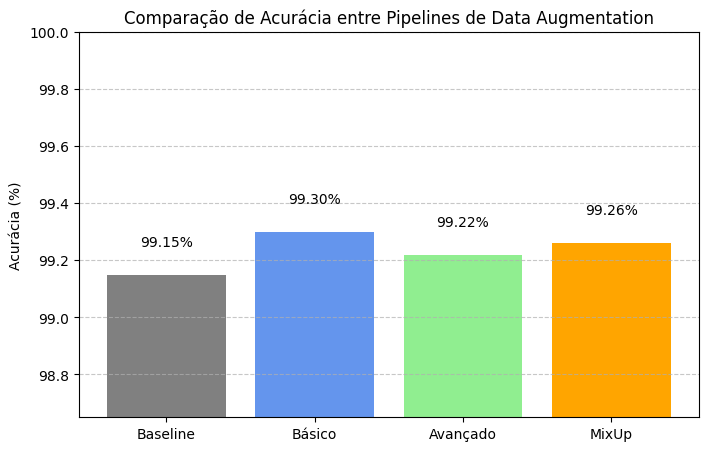

In [26]:
import matplotlib.pyplot as plt

nomes = list(modelos.keys())
acuracias = []
for nome in nomes:
    modelo = modelos[nome]
    modelo.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = modelo(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acuracias.append(100 * correct / total)

plt.figure(figsize=(8,5))
bars = plt.bar(nomes, acuracias, color=['gray', 'cornflowerblue', 'lightgreen', 'orange'])
plt.ylabel('Acurácia (%)')
plt.title('Comparação de Acurácia entre Pipelines de Data Augmentation')
plt.ylim(min(acuracias)-0.5, 100)
for bar, acc in zip(bars, acuracias):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{acc:.2f}%', ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Respostas às questões do exercício:

#### O aumento de dados melhorou a acurácia do modelo?
Sim, todos os pipelines com Data Augmentation tiveram um resultado melhor que o Baseline, isso mostra que as transformações aplicadas melhoraram a capacidade de generalização do modelo.

#### O treinamento ficou mais estável ou mais instável?
O pipeline Avançado apresentou maiores custos de treinamento e oscilantes nas primeiras épocas, porém conforme as epocas passavam as acurácias ficaram estáveis. Os demais mantiveram comportamento estável durante todo o treinamento.

#### Alguma estratégia prejudicou o desempenho?
Eu pensei que o pipeline Avançado, por ser mais "agressivo", fosse prejudicar o desempenho, inclusive o Avançado, conseguiu alcançar uma acurácia de 99,22%, apenas ligeiramente abaixo do melhor resultado, mas ainda muito alta.

#### Qual pipeline apresentou melhor resultado?
O pipeline Básico obteve a maior acurácia de validação (XX,XX%), com pouca diferença do MixUp (XX,XX%).

#### Qual estratégia você escolheria e por quê?
Ao contrario do que imaginei lendo a teoria, apos fazer exemplos praticos, eu escolheria o pipeline Básico, ele ofereceu a melhor acurácia com transformações leves e realistas para dígitos manuscritos, sem custo computacional extra.